## Georgia EI Analysis Using PyEI

In [12]:
import pandas as pd
import numpy as np
import pymc
from pyei.two_by_two import TwoByTwoEI

import os
os.environ["PYTENSOR_FLAGS"] = "cxx=,mode=FAST_COMPILE,linker=py"

import shutil
shutil.rmtree(os.path.expanduser("~\\AppData\\Local\\PyTensor"), ignore_errors=True)

### Path and DataFrame

In [13]:
path = '../output/Georgia/seawulf.csv'

In [14]:
ga_df = pd.read_csv(path)
ga_df

,UNIQUE_ID,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,APPLING-:-1B,108,921,2,1031,1074.216587,102.982480,55.003760,3.618320,1235.821146,"POLYGON ((375680.6717 3535246.721, 375706.5104..."
1,APPLING-:-1C,67,724,0,791,1191.912652,472.673691,42.287709,28.713142,1735.587193,"POLYGON ((378693.0887 3524550.847, 378692.8331..."
2,APPLING-:-2,782,541,4,1327,1235.612661,788.224241,96.849558,32.601383,2153.287844,"POLYGON ((380005.7799 3525000.1826, 380113.838..."
3,APPLING-:-3A1,31,617,0,648,705.543283,121.434717,146.434230,7.825296,981.237527,"POLYGON ((377772.2288 3534595.104, 377753.8538..."
4,APPLING-:-3C,246,934,3,1183,1427.934438,416.186299,57.464584,60.117966,1961.703287,"POLYGON ((386430.8865 3520109.3215, 386469.241..."
...,...,...,...,...,...,...,...,...,...,...,...
2715,WORTH-:-SCOOTERVILLE,33,466,0,499,882.262998,21.675616,59.886046,15.588500,979.413160,"POLYGON ((241750.6763 3468959.4477, 241748.751..."
2716,WORTH-:-SUMNER,115,549,2,666,1053.312665,264.181783,2.612231,59.035993,1379.142672,"POLYGON ((248495.8814 3494258.3435, 248494.668..."
2717,WORTH-:-SYLVESTER,1124,738,4,1866,1166.052147,1077.443185,20.669560,38.311600,2302.476493,"POLYGON ((216948.6246 3494724.9875, 216948.695..."
2718,WORTH-:-SYLVESTER EAST,211,1019,3,1233,1586.468847,147.357490,90.820364,159.706155,1984.352857,"POLYGON ((235331.0428 3502013.0719, 235645.208..."


In [23]:
ga_df[ga_df.isna().any(axis=1)]

,unique_id,kamala d. harris,donald j. trump,other_candidates,total_votes,white_population,black_population,latino_population,other_population,total_population,geometry


### Isolate Columns Needed + Create Columns Necessary

[Source](https://github.com/mggg/ecological-inference/blob/main/pyei/intro_notebooks/PyEI_overview.ipynb?short_path=f3688a3)

Whether you are using an example data set or your own data, here is what you will need to pass to the various EI methods:

A vector of length `num_precincts` giving the population of each precincts. Depending on your purposes and data, the appropriate measure of population may be CVAP, VAP, etc. Below we name this `precinct_pops`.

For 2 x 2 EI:

- A vector of length `num_precincts` whose entries are each numbers between zero and 1 that give the fraction of the population of each precinct who belong to the demographic group of interest. Below we name this `group_fraction`.
- A vector of length `num_precincts` whose entries are each numbers beteween zero and 1 that give the fraction of voters in each precinct voting for the candidate of interest (or, if we are estimating turnout, who voted at all). Below, we name this `votes_fraction`.
Optionally: name of the candidate of interest, name of the demographic group of interest, and/or names of precincts (for use in PyEI's plotting and reporting).

In [15]:
demographics = ['white', 'black', 'latino', 'other']
candidates = ['harris', 'trump']
ga_df.columns = ga_df.columns.str.lower()

ga_data = ga_df[['unique_id', 'kamala d. harris', 'donald j. trump', 'total_votes', 
                 'white_population', 'black_population', 'latino_population', 'other_population', 'total_population']]
ga_data = ga_data.rename(columns={'unique_id' : 'precincts', 'kamala d. harris' : 'harris', 'donald j. trump' : 'trump'})
ga_data['total'] = ga_data['harris'] + ga_data['trump']
ga_data

,precincts,harris,trump,total_votes,white_population,black_population,latino_population,other_population,total_population,total
0,APPLING-:-1B,108,921,1031,1074.216587,102.982480,55.003760,3.618320,1235.821146,1029
1,APPLING-:-1C,67,724,791,1191.912652,472.673691,42.287709,28.713142,1735.587193,791
2,APPLING-:-2,782,541,1327,1235.612661,788.224241,96.849558,32.601383,2153.287844,1323
3,APPLING-:-3A1,31,617,648,705.543283,121.434717,146.434230,7.825296,981.237527,648
4,APPLING-:-3C,246,934,1183,1427.934438,416.186299,57.464584,60.117966,1961.703287,1180
...,...,...,...,...,...,...,...,...,...,...
2715,WORTH-:-SCOOTERVILLE,33,466,499,882.262998,21.675616,59.886046,15.588500,979.413160,499
2716,WORTH-:-SUMNER,115,549,666,1053.312665,264.181783,2.612231,59.035993,1379.142672,664
2717,WORTH-:-SYLVESTER,1124,738,1866,1166.052147,1077.443185,20.669560,38.311600,2302.476493,1862
2718,WORTH-:-SYLVESTER EAST,211,1019,1233,1586.468847,147.357490,90.820364,159.706155,1984.352857,1230


In [29]:
ga_df[ga_df['total_votes'] == 0]

,unique_id,kamala d. harris,donald j. trump,other_candidates,total_votes,white_population,black_population,latino_population,other_population,total_population,geometry
122,BRYAN-:-FTSTEW,0,0,0,0,2.728220,0.506801,0.214689,0.158535,3.608246,"POLYGON ((461733.2922 3533528.8103, 461723.235..."
312,CHATHAM-:-FTPUL,0,0,0,0,505.216006,0.161682,0.179615,30.207854,535.765158,"POLYGON ((498107.4699 3550799.0936, 498110.977..."
313,CHATTAHOOCHEE-:-FTBEN1,0,0,0,0,362.627369,67.232616,90.892690,85.210009,605.962684,"POLYGON ((140226.6065 3592726.1341, 140248.202..."
314,CHATTAHOOCHEE-:-FTBEN2,0,0,0,0,1237.024410,424.797874,681.923882,232.810288,2576.556455,"POLYGON ((142681.5708 3581099.4975, 142699.441..."
315,CHATTAHOOCHEE-:-FTBEN3,0,0,0,0,1506.803847,654.189024,518.504122,187.511630,2867.008624,"POLYGON ((127336.0954 3581480.9947, 127320.923..."
1210,FULTON-:-03P1B,0,0,0,0,14.720144,126.658786,3.434322,2.441324,147.254577,"POLYGON ((185069.3653 3741941.4784, 185085.401..."
1274,FULTON-:-08F2,0,0,0,0,58.760066,6.561895,3.071388,0.004444,68.397793,"POLYGON ((180172.3456 3748325.6436, 180178.791..."
1294,FULTON-:-09J,0,0,0,0,130.948495,45.568073,14.480951,8.024131,199.021651,"POLYGON ((182219.7507 3743818.7381, 182159.490..."
1325,FULTON-:-11C4,0,0,0,0,0.898842,37.785651,0.000315,0.955164,39.639972,"POLYGON ((175549.8934 3738073.4622, 175530.584..."
1342,FULTON-:-12E2,0,0,0,0,8.967233,1.777986,1.932593,0.463822,13.141635,"POLYGON ((182485.0665 3728466.2692, 182011.834..."


In [16]:
def calculate_shares(df):
    result = df[['precincts', 'total']].copy()

    for demographic in demographics:
        result[f'{demographic}_pct'] = (
            df[f'{demographic}_population'] / df['total_population']
        )

    for candidate in candidates:
        result[f'{candidate}_pct'] = (
            df[candidate] / df['total_votes']
        )

    return result

In [20]:
data = calculate_shares(ga_data)
data

,precincts,total,white_pct,black_pct,latino_pct,other_pct,harris_pct,trump_pct
0,APPLING-:-1B,1029,0.869233,0.083331,0.044508,0.002928,0.104753,0.893307
1,APPLING-:-1C,791,0.686749,0.272342,0.024365,0.016544,0.084703,0.915297
2,APPLING-:-2,1323,0.573826,0.366056,0.044978,0.015140,0.589299,0.407687
3,APPLING-:-3A1,648,0.719034,0.123757,0.149234,0.007975,0.047840,0.952160
4,APPLING-:-3C,1180,0.727905,0.212156,0.029293,0.030646,0.207946,0.789518
...,...,...,...,...,...,...,...,...
2715,WORTH-:-SCOOTERVILLE,499,0.900808,0.022131,0.061145,0.015916,0.066132,0.933868
2716,WORTH-:-SUMNER,664,0.763745,0.191555,0.001894,0.042806,0.172673,0.824324
2717,WORTH-:-SYLVESTER,1862,0.506434,0.467950,0.008977,0.016639,0.602358,0.395498
2718,WORTH-:-SYLVESTER EAST,1230,0.799489,0.074260,0.045768,0.080483,0.171127,0.826440


In [19]:
ga_df.isna().any()

unique_id            False
kamala d. harris     False
donald j. trump      False
other_candidates     False
total_votes          False
white_population     False
black_population     False
latino_population    False
other_population     False
total_population     False
geometry             False
dtype: bool

In [17]:
data.isna().any()

precincts     False
total         False
white_pct      True
black_pct      True
latino_pct     True
other_pct      True
harris_pct     True
trump_pct      True
dtype: bool

In [22]:
data[data.isna().any(axis=1)]

,precincts,total,white_pct,black_pct,latino_pct,other_pct,harris_pct,trump_pct
122,BRYAN-:-FTSTEW,0,0.756107,0.140456,0.059500,0.043937,NaN,NaN
312,CHATHAM-:-FTPUL,0,0.942980,0.000302,0.000335,0.056383,NaN,NaN
313,CHATTAHOOCHEE-:-FTBEN1,0,0.598432,0.110952,0.149997,0.140619,NaN,NaN
314,CHATTAHOOCHEE-:-FTBEN2,0,0.480108,0.164870,0.264665,0.090357,NaN,NaN
315,CHATTAHOOCHEE-:-FTBEN3,0,0.525567,0.228178,0.180852,0.065403,NaN,NaN
1210,FULTON-:-03P1B,0,0.099964,0.860135,0.023322,0.016579,NaN,NaN
1274,FULTON-:-08F2,0,0.859093,0.095937,0.044905,0.000065,NaN,NaN
1294,FULTON-:-09J,0,0.657961,0.228960,0.072761,0.040318,NaN,NaN
1325,FULTON-:-11C4,0,0.022675,0.953221,0.000008,0.024096,NaN,NaN
1342,FULTON-:-12E2,0,0.682353,0.135294,0.147059,0.035294,NaN,NaN


In [7]:
print("group col:", data['white_pct'].describe())
print("total col:", data['total'].describe())  # or whatever your denominator is
print("votes col:", data['trump_pct'].describe())
print("votes total:", data['total'].describe())

group col: count    2719.000000
mean        0.543902
std         0.285241
min         0.000000
25%         0.324468
50%         0.595090
75%         0.783456
max         0.998239
Name: white_pct, dtype: float64
total col: count     2720.000000
mean      1915.858088
std       1540.757168
min          0.000000
25%        872.750000
50%       1622.500000
75%       2563.250000
max      17695.000000
Name: total, dtype: float64
votes col: count    2694.000000
mean        0.486685
std         0.275172
min         0.000000
25%         0.245048
50%         0.499833
75%         0.734242
max         1.000000
Name: trump_pct, dtype: float64
votes total: count     2720.000000
mean      1915.858088
std       1540.757168
min          0.000000
25%        872.750000
50%       1622.500000
75%       2563.250000
max      17695.000000
Name: total, dtype: float64


## Fitting Model

In [8]:
def fit_king_99(demographic, candidate):
    group_fraction = np.array(data[f"{demographic}_pct"])
    votes_fraction = np.array(data[f"{candidate}_pct"])

    precinct_pops = np.array(data["total"])
    precinct_names = data['precincts']

    ei = TwoByTwoEI(model_name="king99", lmbda=0.5)

    # Fit the model
    ei.fit(group_fraction, 
        votes_fraction, 
        precinct_pops, 
        demographic_group_name=demographic, 
        candidate_name=candidate, 
        precinct_names=precinct_names, 
        draws=1200, # optional
        tune=3000, # optional
        target_accept=.99 # optional
    )

    print(ei.summary())

    return ei


In [9]:
def fit_king_99_modif(demographic, candidate):
    group_fraction = np.array(data[f"{demographic}_pct"])
    votes_fraction = np.array(data[f"{candidate}_pct"])

    precinct_pops = np.array(data["total"])
    precinct_names = data['precincts']

    print("group_fraction range:", group_fraction.min(), group_fraction.max())
    print("votes_fraction range:", votes_fraction.min(), votes_fraction.max())
    print("Any NaN:", np.isnan(group_fraction).any(), np.isnan(votes_fraction).any())
    print("Any zeros in pop:", (precinct_pops == 0).any())

    ei = TwoByTwoEI(model_name="king99_pareto_modification", pareto_scale=15, pareto_shape=2)

    # Fit the model
    ei.fit(group_fraction, 
        votes_fraction, 
        precinct_pops, 
        demographic_group_name=demographic, 
        candidate_name=candidate, 
        precinct_names=precinct_names, 
        draws=1200, # optional
        tune=3000, # optional
        target_accept=.99 # optional
    )

    print(ei.summary())

    return ei


In [10]:
ei_orig = fit_king_99_modif('white', 'trump')

group_fraction range: nan nan
votes_fraction range: nan nan
Any NaN: True True
Any zeros in pop: True


c:\Users\leeh1\Rockies-Gerrymandering\repo\rockies\Lib\site-packages\pymc\model\core.py:1302: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
c:\Users\leeh1\Rockies-Gerrymandering\repo\rockies\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in votes_count contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


ValueError: Model can not be sampled with NUTS alone. It either has discrete variables or a non-differentiable log-probability.

(<Axes: xlabel='Support for trump'>, <Axes: title={'center': 'EI Summary'}>)

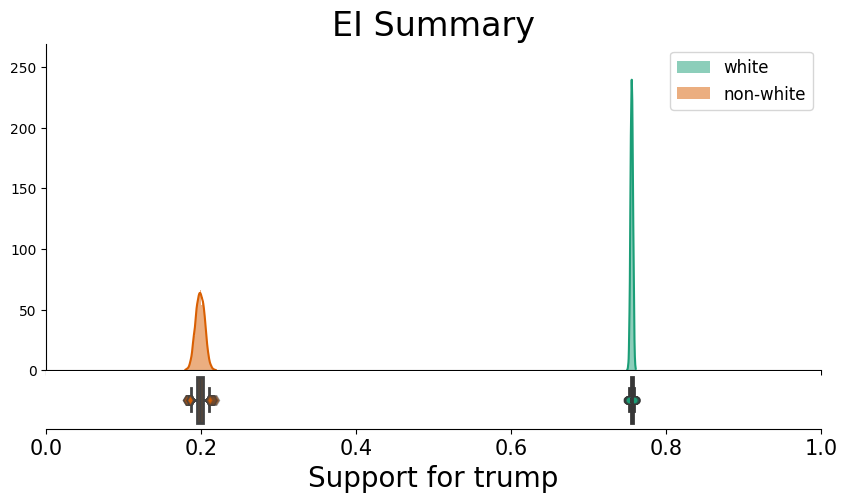

In [ ]:
ei_orig.plot()

(<Axes: xlabel='Support for trump'>, <Axes: title={'center': 'EI Summary'}>)

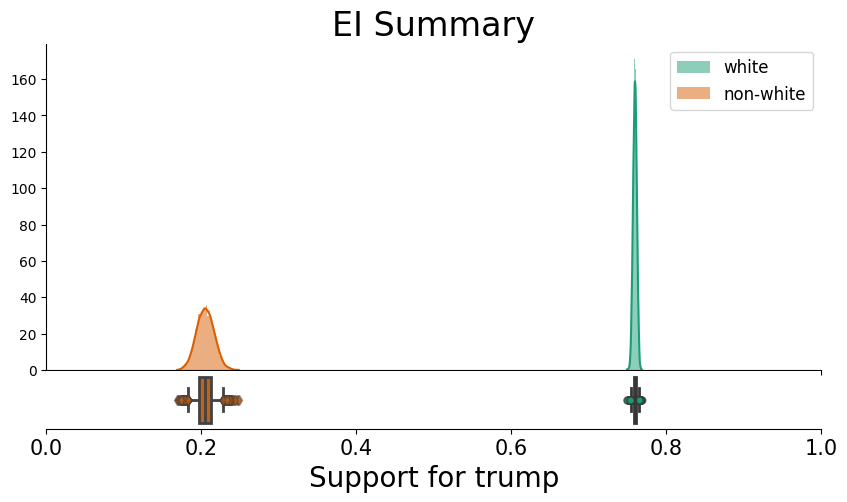

In [ ]:
ei_orig.plot()

In [ ]:
ei_orig = fit_king_99('other', 'trump')

Compiling.. :   0%|          | 0/2500 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2500 [00:03<?, ?it/s]


Running chain 0:   5%|▌         | 125/2500 [00:19<05:13,  7.57it/s]



Running chain 0:  10%|█         | 250/2500 [00:25<02:59, 12.56it/s]


Running chain 0:  20%|██        | 500/2500 [00:35<01:48, 18.45it/s]

Running chain 0:  30%|███       | 750/2500 [00:44<01:16, 22.91it/s]

Running chain 0:  40%|████      | 1000/2500 [00:53<00:56, 26.32it/s]

Running chain 0:  50%|█████     | 1250/2500 [01:04<00:52, 23.90it/s]

Running chain 0:  60%|██████    | 1500/2500 [01:16<00:45, 22.21it/s]

Running chain 0:  65%|██████▌   | 1625/2500 [01:25<00:47, 18.54it/s]





Running chain 0:  75%|███████▌  | 1875/2500 [01:45<00:41, 14.98it/s]

Running chain 0:  85%|████████▌ | 2125/2500 [02:01<00:24, 15.04it/s]

Running chain 0: 100%|██████████| 2500/2500 [02:28<00:00, 16.86it/s]













Running chain 1: 100%|██████████| 2500/2500 [03:58<00:00, 10.50it/s]



Running chain 2: 100%|█

Model: king99
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        other for trump is
        0.119
        The posterior mean for the district-level voting preference of
        non-other for trump is
        0.665
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        other for trump is
        [0.06452242 0.1893792 ]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-other for trump is
        [0.66133968 0.66720391]
        


(<Axes: xlabel='Support for trump'>, <Axes: title={'center': 'EI Summary'}>)

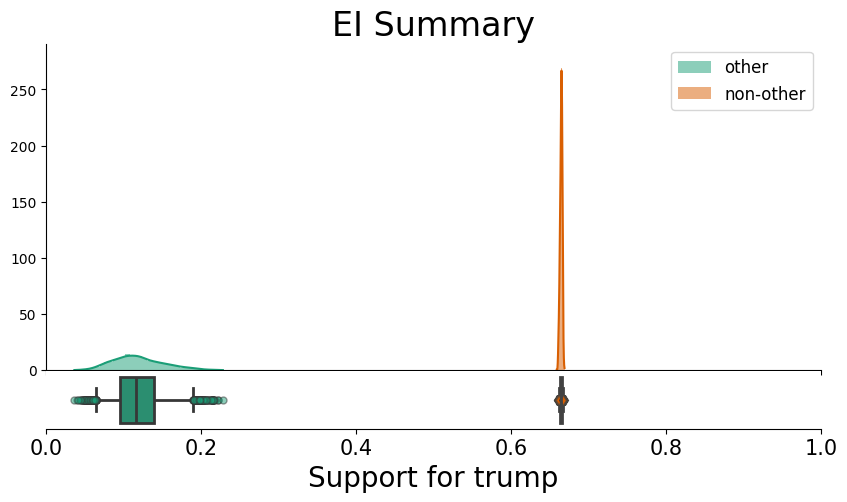

In [ ]:
ei_orig.plot()